In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
print("All imports successful ✓")

All imports successful ✓


In [3]:
app_train = pd.read_csv('../data/application_train.csv')
app_test = pd.read_csv('../data/application_test.csv')
bureau = pd.read_csv('../data/bureau.csv')
prev_app = pd.read_csv('../data/previous_application.csv')

print("application_train:", app_train.shape)
print("application_test: ", app_test.shape)
print("bureau:           ", bureau.shape)
print("previous_app:     ", prev_app.shape)

application_train: (307511, 122)
application_test:  (48744, 121)
bureau:            (1716428, 17)
previous_app:      (1670214, 37)


In [4]:
app_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
print("Total rows:   ", app_train.shape[0])
print("Total columns:", app_train.shape[1])
print("\nColumn data types:")
print(app_train.dtypes.value_counts())

Total rows:    307511
Total columns: 122

Column data types:
float64    65
int64      41
object     16
Name: count, dtype: int64


No Default (0): 282686 → 91.9 %
Default    (1): 24825 → 8.1 %


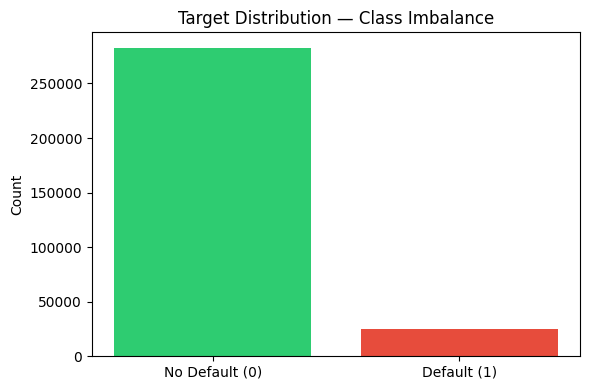

In [6]:
count_no_default = app_train['TARGET'].value_counts()[0]
count_default = app_train['TARGET'].value_counts()[1]
total = len(app_train)

print("No Default (0):", count_no_default, "→", round(count_no_default / total * 100, 1), "%")
print("Default    (1):", count_default, "→", round(count_default / total * 100, 1), "%")

plt.figure(figsize=(6, 4))
plt.bar(['No Default (0)', 'Default (1)'],
        [count_no_default, count_default],
        color=['#2ecc71', '#e74c3c'])
plt.title('Target Distribution — Class Imbalance')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../outputs/class_imbalance.png')
plt.show()

In [6]:
missing_count = app_train.isnull().sum()
missing_count = missing_count[missing_count > 0]
missing_count = missing_count.sort_values(ascending=False)

missing_percent = (missing_count / len(app_train)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent
})

print("Columns with missing values:", len(missing_df))
print("\nTop 20:")
print(missing_df.head(20))

Columns with missing values: 67

Top 20:
                          Missing Count  Missing %
COMMONAREA_MEDI                  214865  69.872297
COMMONAREA_AVG                   214865  69.872297
COMMONAREA_MODE                  214865  69.872297
NONLIVINGAPARTMENTS_MEDI         213514  69.432963
NONLIVINGAPARTMENTS_MODE         213514  69.432963
NONLIVINGAPARTMENTS_AVG          213514  69.432963
FONDKAPREMONT_MODE               210295  68.386172
LIVINGAPARTMENTS_MODE            210199  68.354953
LIVINGAPARTMENTS_MEDI            210199  68.354953
LIVINGAPARTMENTS_AVG             210199  68.354953
FLOORSMIN_MODE                   208642  67.848630
FLOORSMIN_MEDI                   208642  67.848630
FLOORSMIN_AVG                    208642  67.848630
YEARS_BUILD_MODE                 204488  66.497784
YEARS_BUILD_MEDI                 204488  66.497784
YEARS_BUILD_AVG                  204488  66.497784
OWN_CAR_AGE                      202929  65.990810
LANDAREA_AVG                     182590  

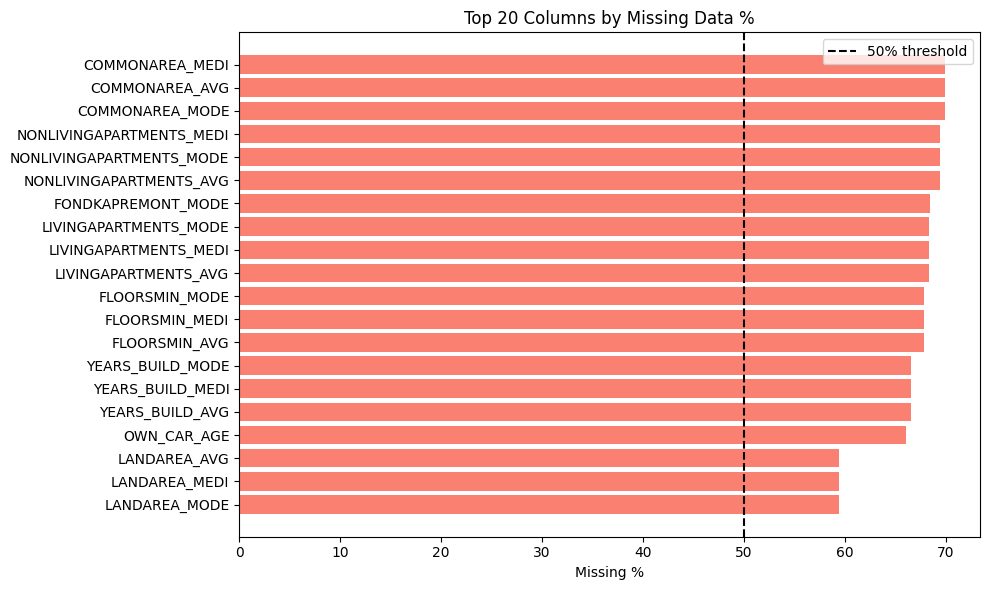

In [7]:
top20 = missing_df.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top20.index, top20['Missing %'], color='salmon')
plt.axvline(x=50, color='black', linestyle='--', label='50% threshold')
plt.title('Top 20 Columns by Missing Data %')
plt.xlabel('Missing %')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

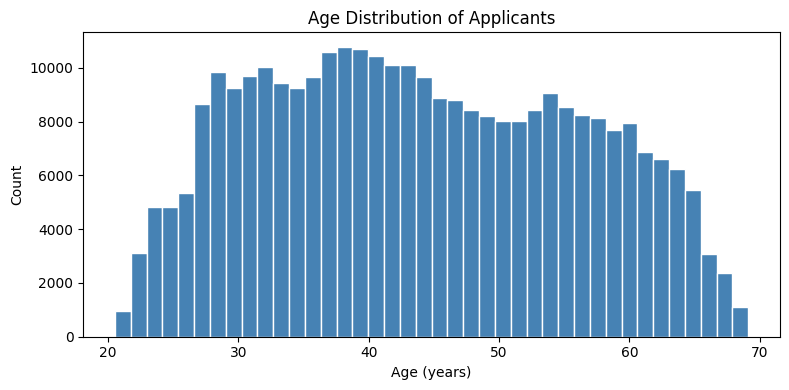

In [7]:
app_train['AGE'] = app_train['DAYS_BIRTH'] / -365

plt.figure(figsize=(8, 4))
plt.hist(app_train['AGE'], bins=40, color='steelblue', edgecolor='white')
plt.title('Age Distribution of Applicants')
plt.xlabel('Age (years)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../outputs/age_distribution.png')
plt.show()

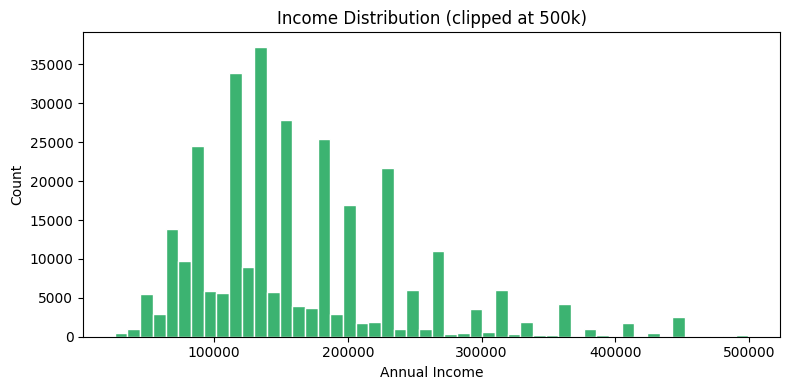

In [8]:
income = app_train['AMT_INCOME_TOTAL']
income_clipped = income[income < 500000]

plt.figure(figsize=(8, 4))
plt.hist(income_clipped, bins=50, color='mediumseagreen', edgecolor='white')
plt.title('Income Distribution (clipped at 500k)')
plt.xlabel('Annual Income')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../outputs/income_distribution.png')
plt.show()

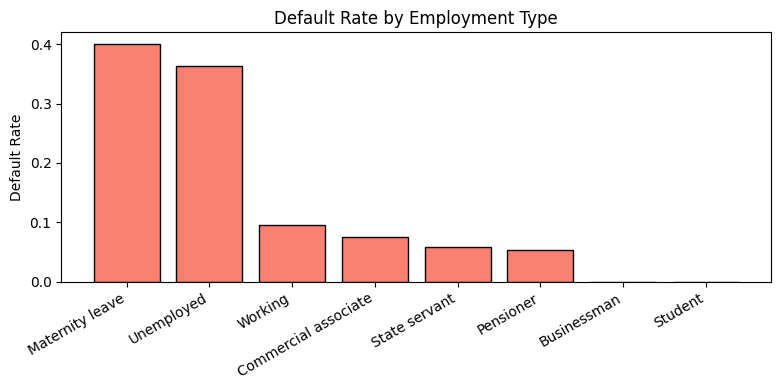

In [9]:
emp_groups = app_train.groupby('NAME_INCOME_TYPE')['TARGET'].mean()
emp_groups = emp_groups.sort_values(ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(emp_groups.index, emp_groups.values, color='salmon', edgecolor='black')
plt.title('Default Rate by Employment Type')
plt.ylabel('Default Rate')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../outputs/default_by_employment.png')
plt.show()

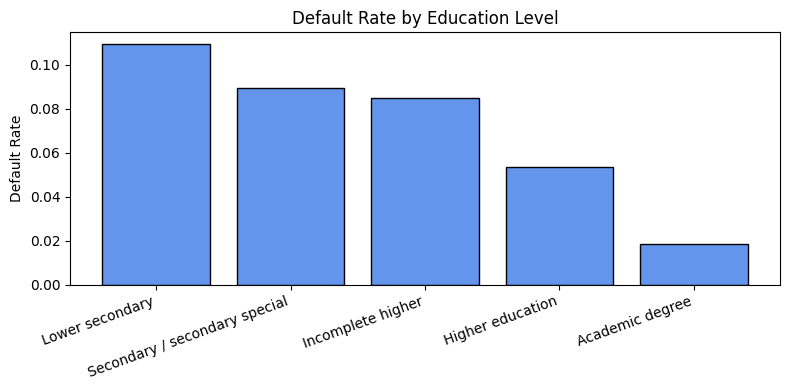

In [10]:
edu_groups = app_train.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean()
edu_groups = edu_groups.sort_values(ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(edu_groups.index, edu_groups.values, color='cornflowerblue', edgecolor='black')
plt.title('Default Rate by Education Level')
plt.ylabel('Default Rate')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('../outputs/default_by_education')
plt.show()

Avg Loan-to-Income (Defaulters):     3.89
Avg Loan-to-Income (Non-Defaulters): 3.96


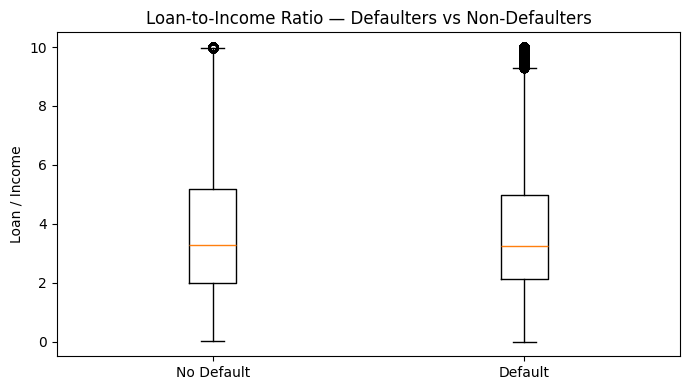

In [12]:
app_train['LOAN_TO_INCOME'] = app_train['AMT_CREDIT'] / app_train['AMT_INCOME_TOTAL']

defaulters = app_train[app_train['TARGET'] == 1]['LOAN_TO_INCOME']
non_defaulters = app_train[app_train['TARGET'] == 0]['LOAN_TO_INCOME']

print("Avg Loan-to-Income (Defaulters):    ", round(defaulters.mean(), 2))
print("Avg Loan-to-Income (Non-Defaulters):", round(non_defaulters.mean(), 2))

plt.figure(figsize=(7, 4))
plt.boxplot([non_defaulters.clip(upper=10), defaulters.clip(upper=10)],
            labels=['No Default', 'Default'])
plt.title('Loan-to-Income Ratio — Defaulters vs Non-Defaulters')
plt.ylabel('Loan / Income')
plt.tight_layout()
plt.show()

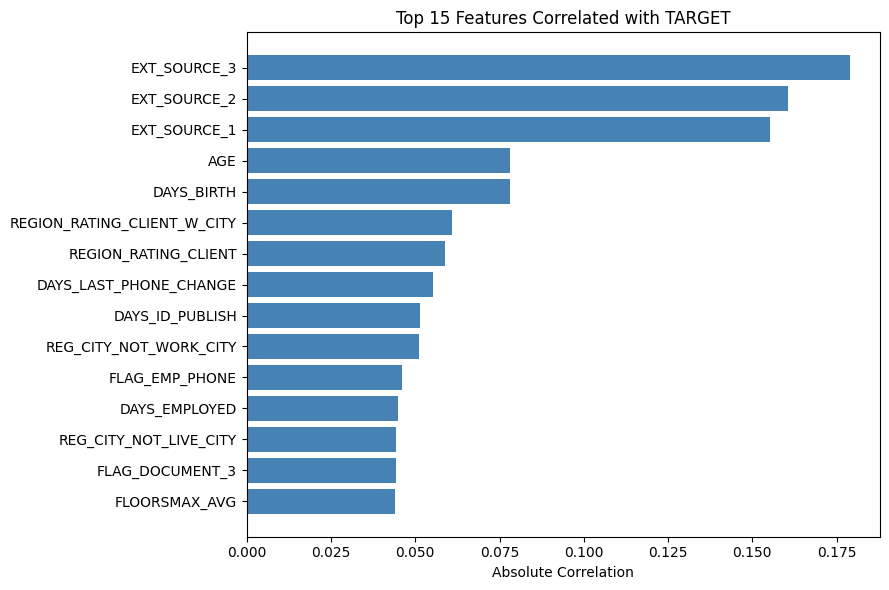

In [11]:
num_cols = app_train.select_dtypes(include='number').columns.tolist()

corr_with_target = app_train[num_cols].corr()['TARGET']
corr_with_target = corr_with_target.drop('TARGET')

abs_corr = corr_with_target.abs()
abs_corr = abs_corr.sort_values(ascending=False)
top15 = abs_corr.head(15)

plt.figure(figsize=(9, 6))
plt.barh(top15.index[::-1], top15.values[::-1], color='steelblue')
plt.title('Top 15 Features Correlated with TARGET')
plt.xlabel('Absolute Correlation')
plt.tight_layout()
plt.savefig('../outputs/top_correlations.png')
plt.show()

In [14]:
print("Bureau shape:", bureau.shape)
print("\nColumns:")
print(bureau.columns.tolist())
bureau.head()

Bureau shape: (1716428, 17)

Columns:
['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT', 'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE', 'AMT_ANNUITY']


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [15]:
print("Previous application shape:", prev_app.shape)
print("\nColumns:")
print(prev_app.columns.tolist())
prev_app.head()

Previous application shape: (1670214, 37)

Columns:
['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY', 'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'FLAG_LAST_APPL_PER_CONTRACT', 'NFLAG_LAST_APPL_IN_DAY', 'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED', 'NAME_CASH_LOAN_PURPOSE', 'NAME_CONTRACT_STATUS', 'DAYS_DECISION', 'NAME_PAYMENT_TYPE', 'CODE_REJECT_REASON', 'NAME_TYPE_SUITE', 'NAME_CLIENT_TYPE', 'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE', 'CHANNEL_TYPE', 'SELLERPLACE_AREA', 'NAME_SELLER_INDUSTRY', 'CNT_PAYMENT', 'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION', 'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'DAYS_TERMINATION', 'NFLAG_INSURED_ON_APPROVAL']


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
print("=== EDA Summary ===")
print("Total applicants:       ", len(app_train))
print("Default rate:           ", round(app_train['TARGET'].mean() * 100, 1), "%")
print("Total features:         ", app_train.shape[1])
print("Columns with nulls:     ", (app_train.isnull().sum() > 0).sum())
print("Avg Loan-to-Income:     ", round(app_train['LOAN_TO_INCOME'].mean(), 2))
print("\nEDA complete.")

=== EDA Summary ===
Total applicants:        307511
Default rate:            8.1 %
Total features:          124
Columns with nulls:      67
Avg Loan-to-Income:      3.96

EDA complete.
